In [36]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_data, get_features_targets

sns.set_style("whitegrid")

# EDA

## Загрузка данных

In [37]:
df = load_data()
print(f"Shape: {df.shape}")
df.head()

Shape: (1001, 195)


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,2,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


## Пропуски и типы

In [38]:
print(f"Пропуски: {df.isnull().sum().sum()}")
print(f"Типы данных: {df.dtypes.value_counts().to_dict()}")

Пропуски: 0
Типы данных: {dtype('float64'): 107, dtype('int64'): 88}


## Описательная статистика таргетов

In [39]:
targets = ["IC50, mM", "CC50, mM", "SI"]
display(df[targets].describe())
print("Skewness:")
for t in targets:
    print(f"{t}: {df[t].skew():.2f}")

,"IC50, mM","CC50, mM",SI
count,1001.000000,1001.000000,1001.000000
mean,222.805156,589.110728,72.508823
std,402.169734,642.867508,684.482739
min,0.003517,0.700808,0.011489
25%,12.515396,99.999036,1.433333
50%,46.585183,411.039342,3.846154
75%,224.975928,894.089176,16.566667
max,4128.529377,4538.976189,15620.600000


Skewness:
IC50, mM: 3.67
CC50, mM: 1.97
SI: 18.01


## Распределения таргетов

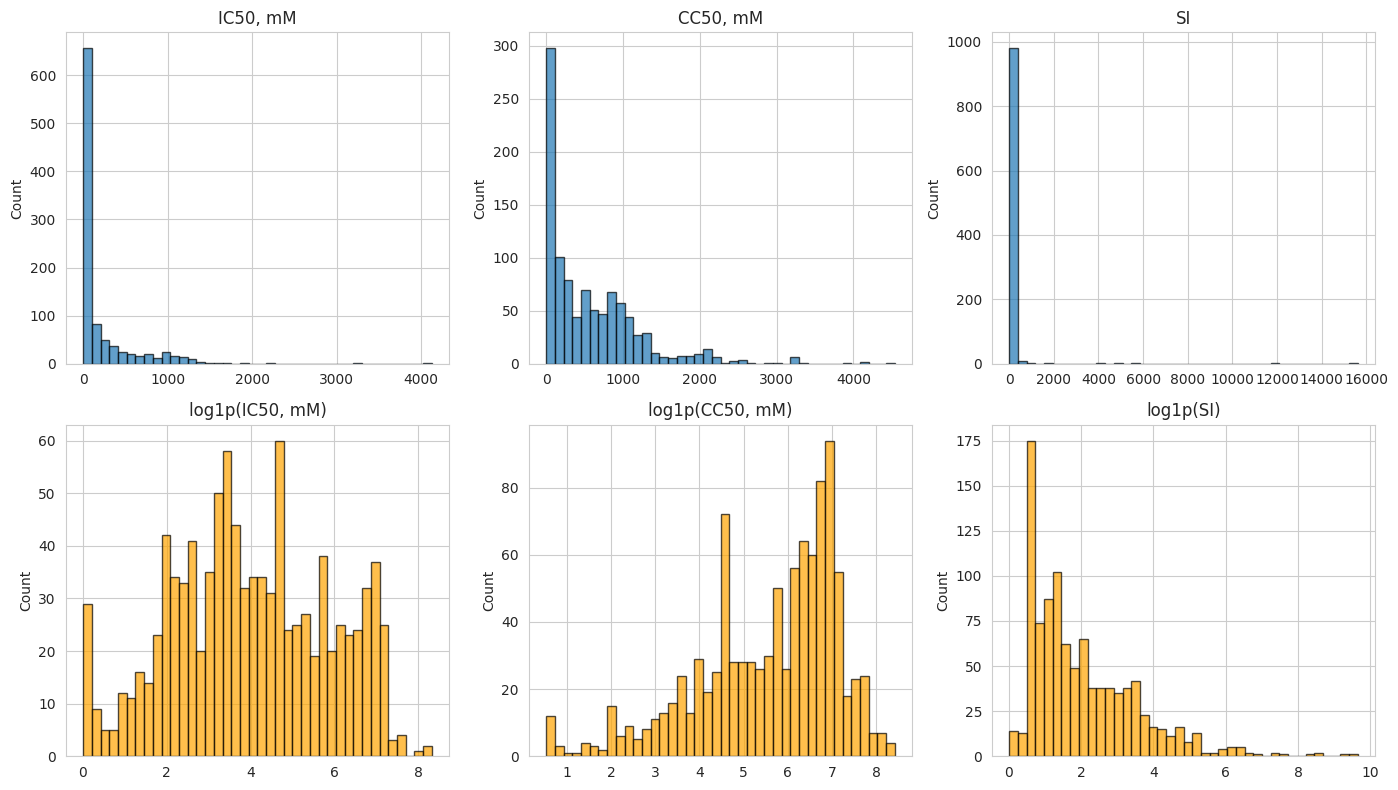

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, t in enumerate(targets):
    axes[0, i].hist(df[t], bins=40, edgecolor="black", alpha=0.7)
    axes[0, i].set_title(t)
    axes[0, i].set_ylabel("Count")

    axes[1, i].hist(np.log1p(df[t]), bins=40, edgecolor="black", alpha=0.7, color="orange")
    axes[1, i].set_title(f"log1p({t})")
    axes[1, i].set_ylabel("Count")

plt.tight_layout()
plt.show()

IC50 после log1p - почти нормальное. CC50 - бимодальное (два пика, ~3.5 и ~6.5), похоже на два подкласса соединений. SI все еще скошен.

## Boxplot таргетов

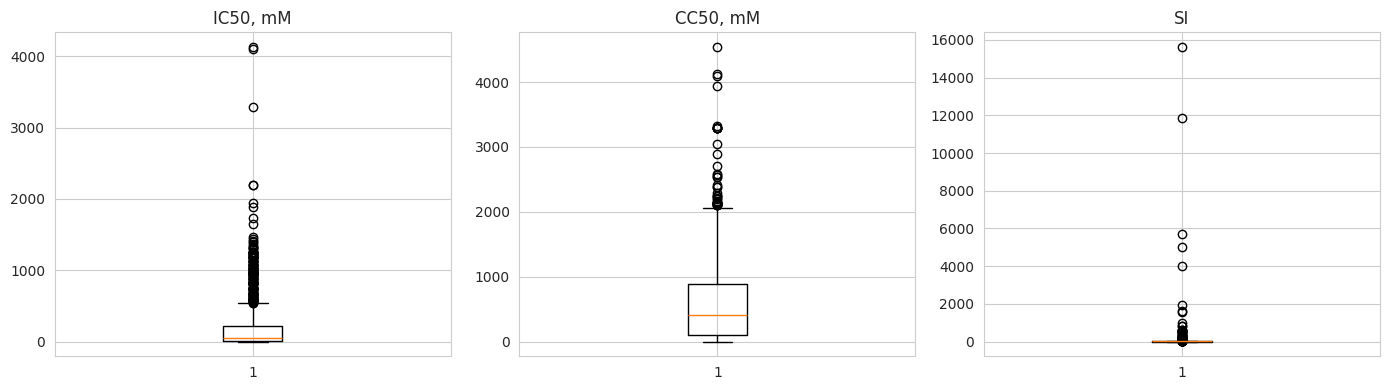

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, t in enumerate(targets):
    axes[i].boxplot(df[t], vert=True)
    axes[i].set_title(t)
plt.tight_layout()
plt.show()

Все три таргета имеют выбросы в правом хвосте.

## Корреляция таргетов

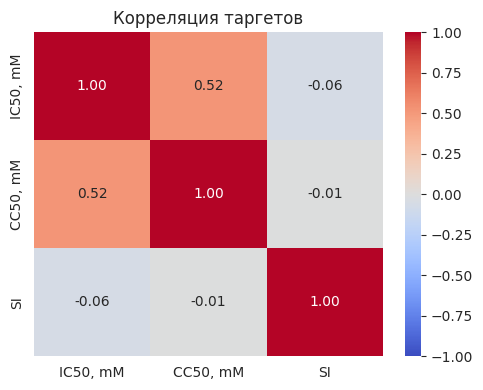

In [42]:
corr_targets = df[targets].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_targets, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1)
ax.set_title("Корреляция таргетов")
plt.tight_layout()
plt.show()

IC50 и CC50 умеренно коррелируют (0.52). SI слабо коррелирует с обоими.

## Топ-20 признаков по корреляции с таргетами

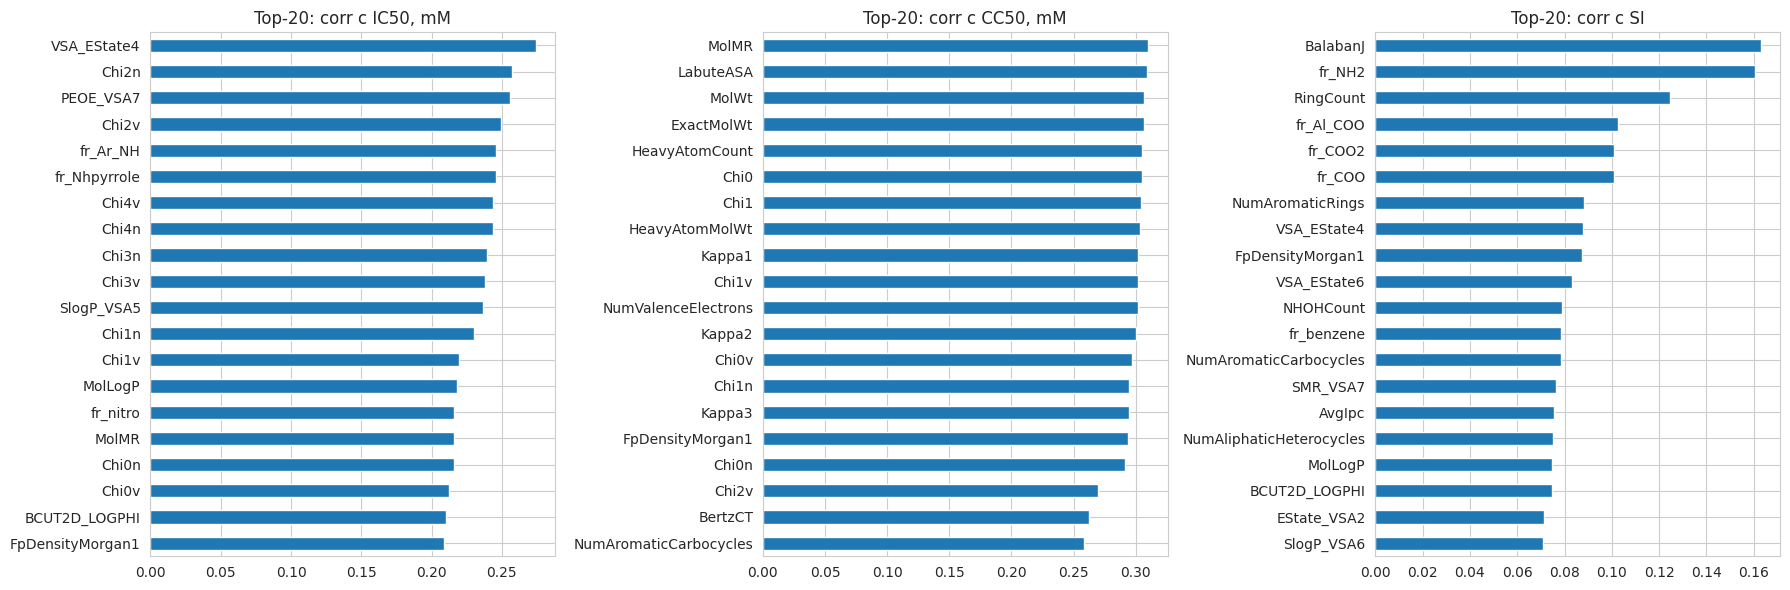

In [43]:
X, tgt = get_features_targets(df)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, t in enumerate(targets):
    corrs = X.corrwith(tgt[t]).abs().sort_values(ascending=False).head(20)
    corrs.plot.barh(ax=axes[i])
    axes[i].set_title(f"Top-20: corr с {t}")
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

## Мультиколлинеарность

In [44]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, upper[col].idxmax(), upper[col].max())
             for col in upper.columns if upper[col].max() > 0.95]
high_corr.sort(key=lambda x: x[2], reverse=True)

print(f"Пар с corr > 0.95: {len(high_corr)}")
pd.DataFrame(high_corr, columns=["Feature 1", "Feature 2", "Correlation"]).head(20)

Пар с corr > 0.95: 33


,Feature 1,Feature 2,Correlation
0,MaxEStateIndex,MaxAbsEStateIndex,1.000000
1,fr_COO2,fr_COO,1.000000
2,fr_Nhpyrrole,fr_Ar_NH,1.000000
3,fr_benzene,NumAromaticCarbocycles,1.000000
4,fr_phenol_noOrthoHbond,fr_phenol,1.000000
5,ExactMolWt,MolWt,0.999999
6,HeavyAtomCount,Chi1,0.998742
7,HeavyAtomMolWt,MolWt,0.996850
8,Chi0,NumValenceElectrons,0.994772
9,LabuteASA,Chi1,0.992866


## Корреляционная матрица (топ-50 признаков)

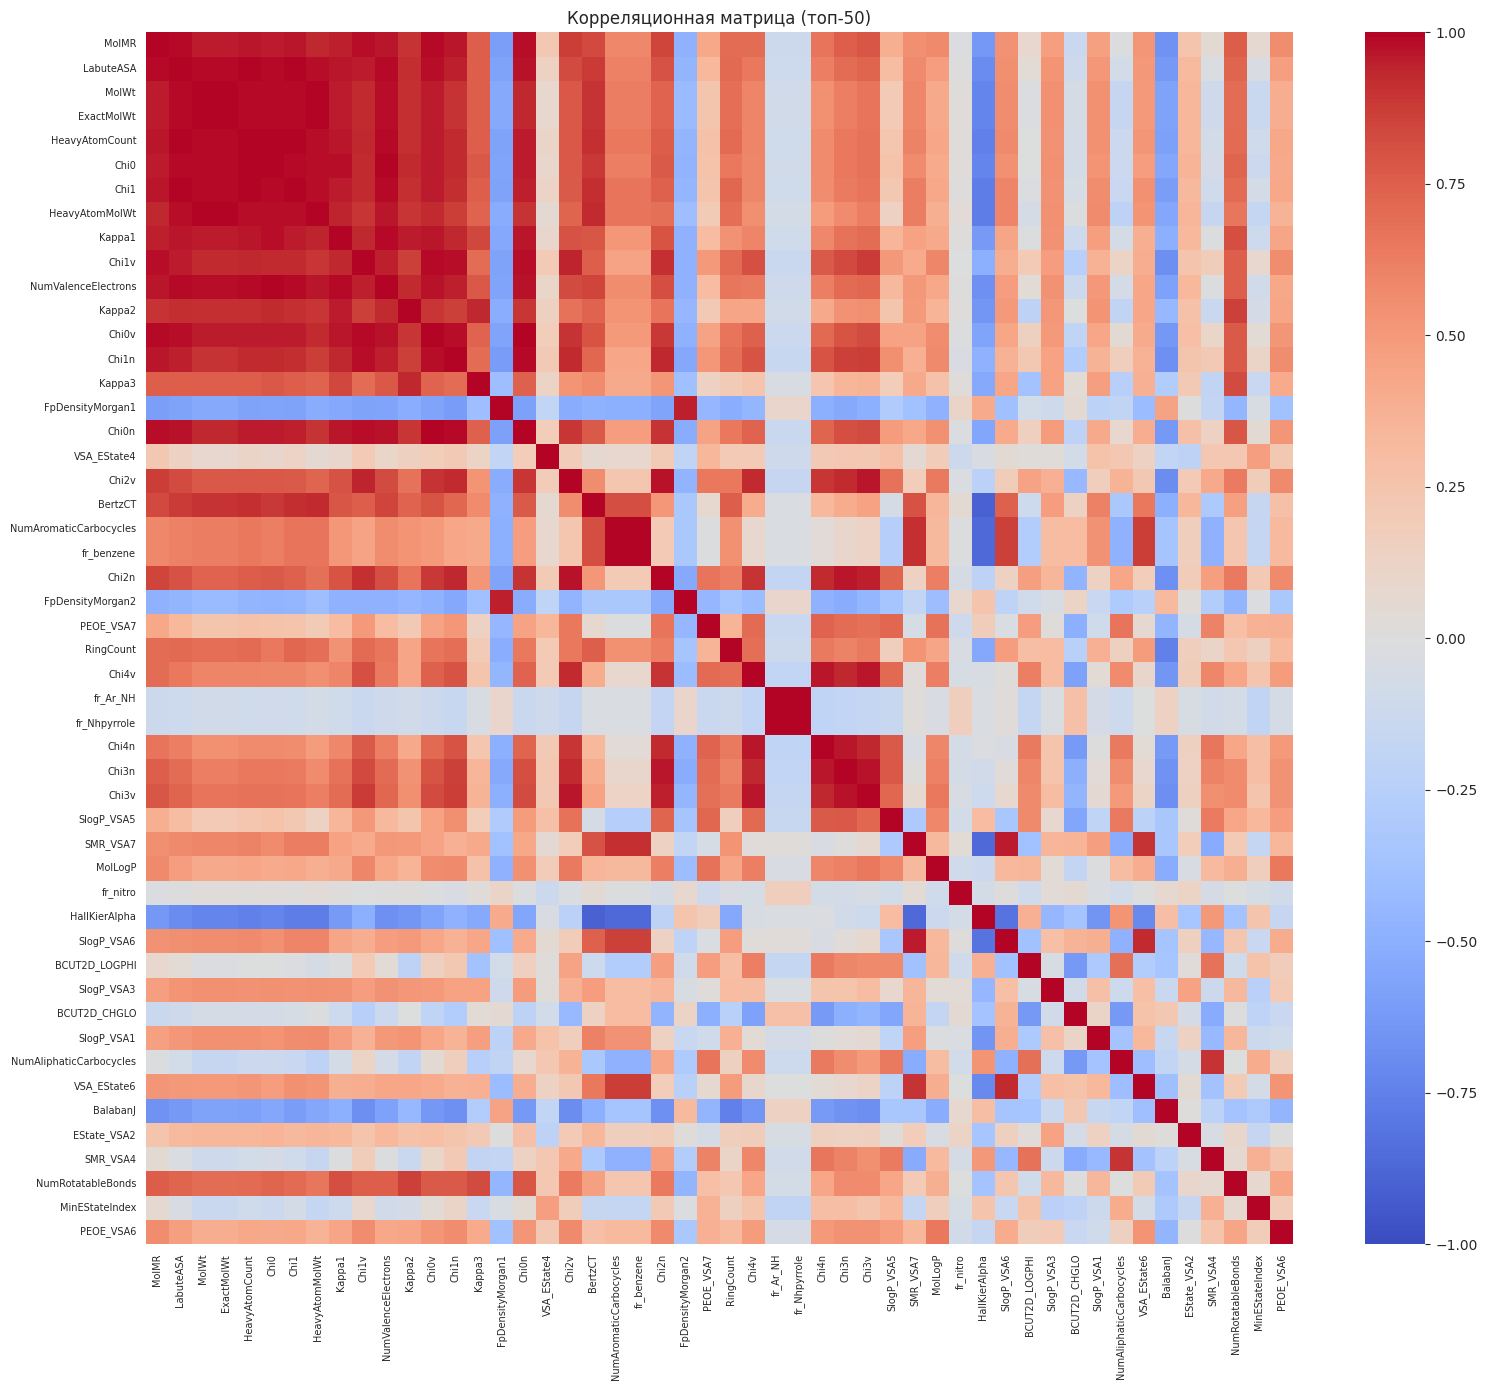

In [45]:
top_features = X.corrwith(tgt.iloc[:, 0]).abs()
for col in tgt.columns[1:]:
    top_features = top_features.combine(X.corrwith(tgt[col]).abs(), max)
top50 = top_features.sort_values(ascending=False).head(50).index

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(X[top50].corr(), cmap="coolwarm", ax=ax, xticklabels=True, yticklabels=True,
            vmin=-1, vmax=1)
ax.set_title("Корреляционная матрица (топ-50)")
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

## PCA

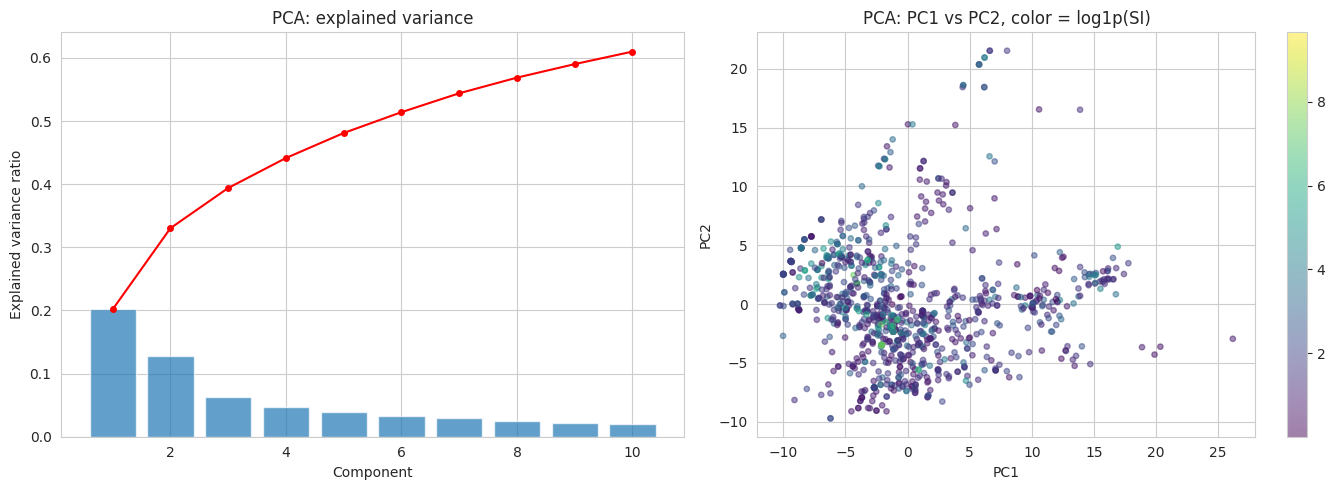

Cumulative variance (10 PC): 0.61


In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 11), pca.explained_variance_ratio_, alpha=0.7)
axes[0].plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_), "r-o", markersize=4)
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("PCA: explained variance")

sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=np.log1p(tgt["SI"]), cmap="viridis",
                     alpha=0.5, s=15)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("PCA: PC1 vs PC2, color = log1p(SI)")
plt.colorbar(sc, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"Cumulative variance (10 PC): {pca.explained_variance_ratio_.sum():.2f}")

## Анализ выбросов

,Target,Q1,Q3,IQR,Lower,Upper,Outliers,%,Max
0,"IC50, mM",12.52,224.98,212.46,0,543.67,147,14.7,4128.53
1,"CC50, mM",100.00,894.09,794.09,0,2085.22,39,3.9,4538.98
2,SI,1.43,16.57,15.13,0,39.27,125,12.5,15620.60


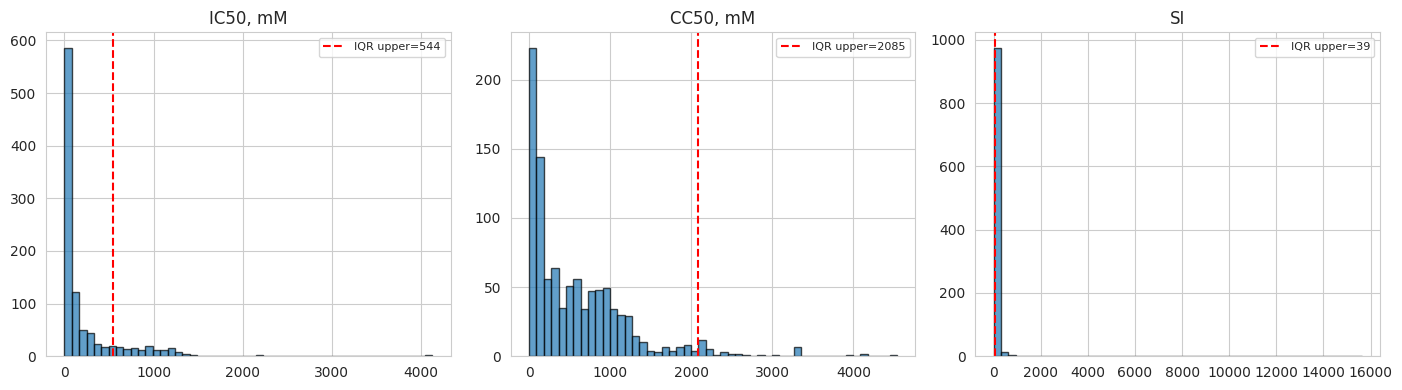

In [47]:
targets = ["IC50, mM", "CC50, mM", "SI"]
outlier_stats = []

for t in targets:
    q1 = df[t].quantile(0.25)
    q3 = df[t].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((df[t] < lower) | (df[t] > upper)).sum()
    outlier_stats.append({
        "Target": t,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "Lower": round(max(lower, 0), 2),
        "Upper": round(upper, 2),
        "Outliers": n_out,
        "%": round(100 * n_out / len(df), 1),
        "Max": round(df[t].max(), 2),
    })

display(pd.DataFrame(outlier_stats))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, t in enumerate(targets):
    q1 = df[t].quantile(0.25)
    q3 = df[t].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    axes[i].hist(df[t], bins=50, edgecolor="black", alpha=0.7)
    axes[i].axvline(upper, color="red", linestyle="--", label=f"IQR upper={upper:.0f}")
    axes[i].set_title(t)
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.show()

Выбросов по IQR много, но удалять не стоит - это реальные соединения, не ошибки. log1p сжимает хвосты, деревья робастны, а терять 10-15% данных при n=1001 нежелательно.

## Выводы

После удаления 18 константных колонок осталось 192 признака. Пропуски (3 строки) заполнены медианой. log1p хорошо работает для IC50, CC50 дает бимодальное распределение, SI остается скошенным. Между признаками много дублей (33 пары с corr > 0.95), так что для линейных моделей нужна регуляризация. PCA: 10 компонент - 61% дисперсии, на scatter по SI разделения нет. Класс SI > 8 составляет 36% выборки.